# Function 4 — Bayesian Optimization Campaign

This notebook documents the search for the input `(x1, x2, x3, x4)` that **maximizes** an
unknown ("black-box") 4D function. A Gaussian Process (GP) surrogate model is fit to the
observed data, and acquisition functions (Upper Confidence Bound, Expected Improvement) are
used to decide which point to query next.

## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import minimize
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C
import torch
import torch.nn as nn
import torch.optim as optim

## 2. Initial Data

In [2]:
X = np.load("function_4/data/initial_inputs.npy")
y = np.load("function_4/data/initial_outputs.npy")

Additional query rounds, appended as results came in:

In [3]:
X = np.append(X, [
    [0.413140, 0.406530, 0.351979, 0.424546],
    [0.000050, 0.406177, 0.000050, 0.999950],
    [0.420869, 0.405212, 0.299525, 0.442236],
    [0.370816, 0.415794, 0.447858, 0.438559],
    [0.413152, 0.408132, 0.387288, 0.426818],
    [0.425258, 0.399638, 0.391427, 0.426754],
    [0.416230, 0.219011, 0.376704, 0.224546],
    [0.500000, 0.500000, 0.200000, 0.200000],
    [0.200000, 0.200000, 0.200000, 0.200000],
    [0.200000, 0.396587, 0.200000, 0.500000],
    [0.391978, 0.411162, 0.399918, 0.431552],
    [0.200000, 0.396587, 0.200000, 0.500000],  # repeat measurement at an existing point
    [0.401978, 0.406162, 0.375918, 0.426552],
    ], axis=0)

y = np.append(y, [
    0.6576375369770244,
    -27.92656455534856,
    -0.8588640837892814,
    0.07512356797425612,
    0.5458025382952418,
    -3.77441428668877,
    0.4862088601122463,
    -4.73465063897795,
    -7.072969050200555,
    -9.992537829880174,
    -6.766976325434015,
    0.39343285565356156,
    0.48974581058413635,
    ], axis=0)

print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"Best observed y so far: {max(y)}")

X shape: (43, 4), y shape: (43,)
Best observed y so far: 0.6576375369770244


## 3. Gaussian Process Surrogate Model

`Matern(nu=2.5)` is robust for higher-dimensional optimization; `alpha` accounts for noise in
the measurements.

In [4]:
kernel = C(1.0) * Matern(length_scale=[0.1] * 4, length_scale_bounds=(0.5, 2.0), nu=2.5)

gp_model = GaussianProcessRegressor(kernel=kernel, alpha=1e-1, n_restarts_optimizer=20)
gp_model.fit(X, y)

/Users/theshiekh/Library/Caches/pypoetry/virtualenvs/emeritus-emhPt3nG-py3.12/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/theshiekh/Library/Caches/pypoetry/virtualenvs/emeritus-emhPt3nG-py3.12/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.5. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/theshiekh/Library/Caches/pypoetry/virtualenvs/emeritus-emhPt3nG-py3.12/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specifi

,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP.If `None` is passed,the kernel `ConstantKernel() * RBF()` is used as default.Note thatthe kernel hyperparameters are optimized during fittingunless the bounds are marked as `""fixed""`or the argument `optimizer` is set to `None`.","1**2 * Matern... 0.1], nu=2.5)"
,"alpha alpha: float or ndarray of shape (n_samples,), default=1e-10Value added to the diagonal of the kernel matrix during fitting.This can prevent a potential numerical issue during fitting, byensuring that the calculated values form a positive definite matrix.It can also be interpreted as the variance of additional Gaussianmeasurement noise on the training observations. Note that this isdifferent from using a `WhiteKernel`. If an array is passed, it musthave the same number of entries as the data used for fitting and isused as datapoint-dependent noise level. Allowing to specify thenoise level directly as a parameter is mainly for convenience andfor consistency with :class:`~sklearn.linear_model.Ridge`.For an example illustrating how the alpha parameter controlsthe noise variance in Gaussian Process Regression, see:ref:`sphx_glr_auto_examples_gaussian_process_plot_gpr_noisy_targets.py`.",0.1
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that `n_restarts_optimizer == 0` implies that onerun is performed.",20
,kernel__k1,1**2
,kernel__k2,"Matern(length... 0.1], nu=2.5)"
,kernel__k1__constant_value,1.0
,kernel__k1__constant_value_bounds,"(1e-05, ...)"
,kernel__k2__length_scale,"[0.1, 0.1, ...]"
,kernel__k2__length_scale_bounds,"(0.5, ...)"
,kernel__k2__nu,2.5
,"optimizer optimizer: ""fmin_l_bfgs_b"", callable or None, default=""fmin_l_bfgs_b""Can either be one of the internally supported optimizers for optimizingthe kernel's parameters, specified by a string, or an externallydefined optimizer passed as a callable. If a callable is passed, itmust have the signature:: def optimizer(obj_func, initial_theta, bounds): # * 'obj_func': the objective function to be minimized, which # takes the hyperparameters theta as a parameter and an # optional flag eval_gradient, which determines if the # gradient is returned additionally to the function value # * 'initial_theta': the initial value for theta, which can be # used by local optimizers # * 'bounds': the bounds on the values of theta .... # Returned are the best found hyperparameters theta and # the corresponding value of the target function. return theta_opt, func_minPer default, the L-BFGS-B algorithm from `scipy.optimize.minimize`is used. If None is passed, the kernel's parameters are kept fixed.Available internal optimizers are: `{'fmin_l_bfgs_b'}`.",'fmin_l_bfgs_b'


## 4. Acquisition Functions

### Upper Confidence Bound (UCB)
`kappa` controls the exploration/exploitation trade-off.

In [5]:
def ucb_loss(x_test, kappa=50):
    mean, std = gp_model.predict(x_test.reshape(1, -1), return_std=True)
    return -(mean + kappa * std)  # minimize the negative UCB to maximize UCB

x_init = X[np.argmax(y)]  # start from current best
res = minimize(ucb_loss, x_init, bounds=[(0.2, 0.5)] * 4, method='L-BFGS-B')

print(f"Current Best Y: {np.max(y)}")
print(f"Suggested Next Iteration Point (UCB): {res.x}")

Current Best Y: 0.6576375369770244
Suggested Next Iteration Point (UCB): [0.5        0.5        0.31358937 0.2       ]


### Expected Improvement (EI)
`xi` is the exploration parameter. The search is bounded locally (+/- 0.2 in each dimension)
around the current best point.

In [6]:
def expected_improvement(x_new, model, current_best_y, xi=0.001):
    x_new = x_new.reshape(1, -1)
    mu, sigma = model.predict(x_new, return_std=True)

    if sigma <= 0:
        return 0.0

    improvement = mu - current_best_y - xi
    z = improvement / sigma

    ei = improvement * norm.cdf(z) + sigma * norm.pdf(z)
    return -ei

current_best_y = np.max(y)
x_best = X[np.argmax(y)]

local_bounds = [
    (max(0, x_best[0] - 0.2), min(1, x_best[0] + 0.2)),
    (max(0, x_best[1] - 0.2), min(1, x_best[1] + 0.2)),
    (max(0, x_best[2] - 0.2), min(1, x_best[2] + 0.2)),
    (max(0, x_best[3] - 0.2), min(1, x_best[3] + 0.2)),
]

x0 = X[np.argmax(y)]
res = minimize(expected_improvement, x0,
               bounds=local_bounds,
               args=(gp_model, current_best_y),
               method='L-BFGS-B')

next_point = res.x
print(f"Suggested Next Iteration Point (EI, local bounds): {next_point}")

Suggested Next Iteration Point (EI, local bounds): [0.36721554 0.60653    0.551979   0.54459756]


Third iteration: shifted from UCB to EI, with bounds narrowed to the current peak, to home in on the local optimum rather than continuing to explore broadly.

### Ranked Observations
A quick sanity check on where the current samples rank by yield.

In [7]:
sorted_indices = np.argsort(y)
sorted_values = y[sorted_indices]

print(f"{'Rank':<6} | {'Orig Index':<10} | {'Value':<10}")
print("-" * 32)
for rank, idx in enumerate(sorted_indices):
    print(f"{rank:<6} | {idx:<10} | {sorted_values[rank]:.2f}")

Rank   | Orig Index | Value     
--------------------------------
0      | 25         | -32.63
1      | 20         | -29.43
2      | 18         | -28.90
3      | 31         | -27.93
4      | 10         | -27.32
5      | 22         | -26.86
6      | 15         | -26.56
7      | 29         | -23.14
8      | 0          | -22.11
9      | 26         | -19.99
10     | 17         | -19.44
11     | 14         | -17.82
12     | 8          | -17.05
13     | 12         | -16.68
14     | 13         | -16.51
15     | 3          | -16.05
16     | 7          | -16.03
17     | 5          | -15.49
18     | 1          | -14.60
19     | 19         | -13.70
20     | 11         | -13.53
21     | 28         | -13.12
22     | 16         | -12.76
23     | 9          | -12.74
24     | 6          | -12.68
25     | 2          | -11.70
26     | 21         | -11.57
27     | 4          | -10.07
28     | 39         | -9.99
29     | 23         | -7.97
30     | 38         | -7.07
31     | 40         | -6.77
32     | 2

## 5. Supplementary Analysis — Neural Network Saliency

Existing samples are manually labeled "positive" (high-yield, indices `[30, 31, 33]`) or
"negative", and a small neural network is trained on that split as a sanity check on whether
the acquisition function's suggested `next_point` also looks promising from a classification
standpoint. This is exploratory and not part of the core GP/acquisition-function decision loop.

In [8]:
y_labels = np.zeros(len(X))
positive_indices = [30, 31, 33]
y_labels[positive_indices] = 1

X_tensor = torch.tensor(X, dtype=torch.float32, requires_grad=True)
y_tensor = torch.tensor(y_labels, dtype=torch.float32).reshape(-1, 1)

nn_model_deep = nn.Sequential(
    nn.Linear(4, 16),
    nn.ReLU(),
    nn.Linear(16, 1),
    nn.Sigmoid()
)

optimizer = optim.Adam(nn_model_deep.parameters(), lr=0.01)
criterion = nn.BCELoss()

for _ in range(2000):
    optimizer.zero_grad()
    outputs = nn_model_deep(X_tensor)
    loss = criterion(outputs, y_tensor)
    loss.backward()
    optimizer.step()

X_tensor.grad.zero_()
output = nn_model_deep(X_tensor)
output.backward(torch.ones_like(output))

deep_importance = X_tensor.grad.abs().sum(dim=1).detach().numpy()

print("Point | Deep Importance Score")
for i, score in enumerate(deep_importance):
    print(f"{i:2d}    | {score:.4f}")

Point | Deep Importance Score
 0    | 0.0000
 1    | 0.0000
 2    | 0.0087
 3    | 0.0000
 4    | 0.3006
 5    | 0.0000
 6    | 0.0114
 7    | 0.0002
 8    | 0.0000
 9    | 0.0176
10    | 0.0000
11    | 0.0000
12    | 0.0000
13    | 0.0000
14    | 0.0001
15    | 0.0077
16    | 0.3694
17    | 0.7787
18    | 0.0000
19    | 0.0000
20    | 0.1920
21    | 0.0000
22    | 0.0000
23    | 0.0000
24    | 0.0001
25    | 0.0000
26    | 0.0000
27    | 0.0140
28    | 0.0000
29    | 0.0000
30    | 11.2731
31    | 1.6138
32    | 6.3643
33    | 20.0613
34    | 14.4420
35    | 7.2027
36    | 0.0216
37    | 0.0380
38    | 0.0182
39    | 1.8389
40    | 22.7563
41    | 1.8389
42    | 19.0461


In [9]:
nn_model_deep.eval()
sample_input = torch.tensor(np.array([next_point]), dtype=torch.float32)

with torch.no_grad():
    prediction_prob = nn_model_deep(sample_input)

print(f"Next point: {next_point}")
print(f"Probability of being Positive (Class 1): {prediction_prob.item():.4f}")
predicted_label = 1 if prediction_prob.item() >= 0.5 else 0
print(f"Predicted Class: {predicted_label}")

Next point: [0.36721554 0.60653    0.551979   0.54459756]
Probability of being Positive (Class 1): 0.0280
Predicted Class: 0


## 6. Results Summary

Observed yield over the most recent iterations:

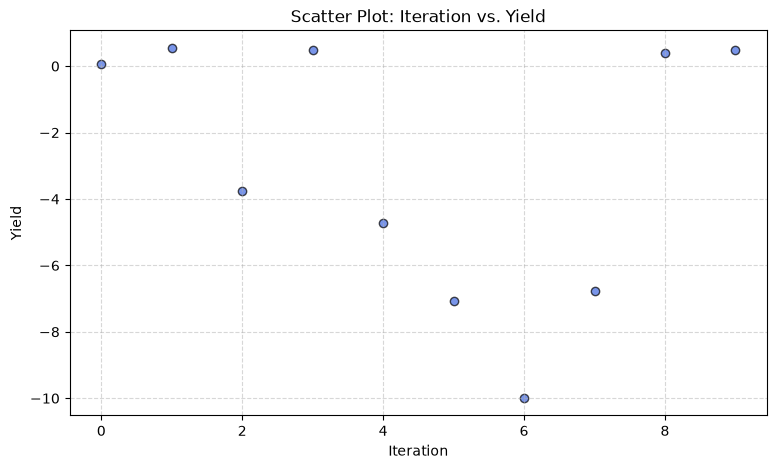

In [10]:
plt.figure(figsize=(9, 5))
plt.scatter(
    list(range(0, 10)), y[-10:], color="royalblue", alpha=0.7, edgecolors="k"
)
plt.title("Scatter Plot: Iteration vs. Yield")
plt.xlabel("Iteration")
plt.ylabel("Yield")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()